## Modeling for predicting critical outcome at ED disposition

Work Flow:
1. Task-specific filter
2. Variable selection
3. Modeling script
4. Performance output


### Load train and test

In [1]:
##USE PYTHON3.10-Rich1.0 KERNEL
import os
import time
import random
import tensorflow as tf
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import optimizers, metrics
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.layers import concatenate
from tensorflow.keras.models import load_model
from helpers import PlotROCCurve, get_lstm_data_gen
from dataset_path import output_path

df_train = pd.read_csv('mv_train_DISPOSITION.csv')
df_test = pd.read_csv('mv_test_DISPOSITION.csv')
df_val = pd.read_csv("mv_val_DISPOSITION.csv")
confidence_interval = 95
random_seed=0

2026-03-15 22:49:01.319992: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-15 22:49:01.351178: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-15 22:49:01.351209: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-15 22:49:01.352330: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-15 22:49:01.358520: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-15 22:49:01.359079: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [2]:
random.seed(random_seed)
np.random.seed(random_seed)

In [3]:
pd.set_option('display.max_columns', 100) 
pd.set_option('display.max_rows', 100) 

df_train.head()

,index,subject_id,hadm_id,stay_id,intime,outtime,anchor_age,gender,anchor_year,dod,admittime,dischtime,deathtime,ethnicity,edregtime,edouttime,insurance,in_year,age,outcome_inhospital_mortality,ed_death,before_ed_mortality,ed_los,intime_icu,time_to_icu_transfer,outcome_icu_transfer_12h,outcome_hospitalization,outcome_critical,n_ed_30d,n_ed_90d,n_ed_365d,next_ed_visit_time,next_ed_visit_time_diff,outcome_ed_revisit_3d,n_hosp_30d,n_hosp_90d,n_hosp_365d,n_icu_30d,n_icu_90d,n_icu_365d,ed_los_hours,time_to_icu_transfer_hours,next_ed_visit_time_diff_days,triage_temperature,triage_heartrate,triage_resprate,triage_o2sat,triage_sbp,triage_dbp,triage_pain,...,eci_CHF,eci_Arrhythmia,eci_Valvular,eci_PHTN,eci_PVD,eci_HTN1,eci_HTN2,eci_Paralysis,eci_NeuroOther,eci_Pulmonary,eci_DM1,eci_DM2,eci_Hypothyroid,eci_Renal,eci_Liver,eci_PUD,eci_HIV,eci_Lymphoma,eci_Tumor2,eci_Tumor1,eci_Rheumatic,eci_Coagulopathy,eci_Obesity,eci_WeightLoss,eci_FluidsLytes,eci_BloodLoss,eci_Anemia,eci_Alcohol,eci_Drugs,eci_Psychoses,eci_Depression,ed_temperature_last,ed_heartrate_last,ed_resprate_last,ed_o2sat_last,ed_sbp_last,ed_dbp_last,ed_pain_last,n_med,n_medrecon,triage_MAP,score_CCI,score_CART,score_REMS,score_NEWS,score_NEWS2,score_MEWS,split,notes,ecg_paths
0,228428,10870475,24160860.0,32267643,2118-02-13 23:54:00,2118-02-14 15:44:00,47,F,2118,NaN,2118-02-14 04:18:00,2118-02-14 15:44:00,NaN,WHITE,2118-02-13 23:54:00,2118-02-14 15:44:00,Other,2118,47,False,False,False,0 days 15:50:00,NaN,NaN,False,True,False,0,0,0,NaN,NaN,False,0,0,0,0,0,0,15.83,NaN,NaN,36.712811,85.085489,17.554838,98.374259,134.906695,77.480026,4.167576,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,37.555556,84.0,18.0,97.0,114.0,74.0,5.0,8.0,0.0,96.622249,0,0,2,0,0,1,train,examination hand pa lat and oblique left indic...,['files/p1087/p10870475/s46566754/46566754']
1,7166,11258835,NaN,31208360,2175-04-18 13:54:00,2175-04-18 13:55:00,77,F,2175,NaN,NaN,NaN,NaN,WHITE,NaN,NaN,NaN,2175,77,False,False,False,0 days 00:01:00,NaN,NaN,False,False,False,0,0,0,2176-04-08 17:38:00,356 days 03:43:00,False,0,0,0,0,0,0,0.02,NaN,356.15,36.444444,73.000000,18.000000,96.000000,187.000000,97.000000,5.000000,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,36.333333,73.0,18.0,97.0,145.0,93.0,0.0,5.0,12.0,127.000000,3,9,8,0,0,1,train,history screening comparison hologic digital s...,['files/p1125/p11258835/s41234765/41234765']
2,163449,19301404,NaN,37156637,2123-06-05 16:49:00,2123-06-05 17:20:00,20,F,2123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2123,20,False,False,False,0 days 00:31:00,NaN,NaN,False,False,False,1,1,1,2123-09-01 17:19:00,87 days 23:59:00,False,0,0,0,0,0,0,0.52,NaN,88.00,35.944444,89.000000,18.000000,100.000000,144.000000,87.000000,8.000000,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,36.888889,80.0,18.0,100.0,111.0,71.0,2.0,1.0,1.0,106.000000,0,0,0,1,1,1,train,examination chest frontal and lateral views in...,['files/p1930/p19301404/s43791199/43791199']
3,40385,17101381,25853393.0,37075184,2130-05-06 16:51:00,2130-05-07 00:48:00,43,F,2125,NaN,2130-05-06 22:02:00,2130-05-08 14:45:00,NaN,WHITE,2130-05-06 16:51:00,2130-05-07 00:48:00,Other,2130,48,False,False,False,0 days 07:57:00,NaN,NaN,False,True,False,0,0,0,NaN,NaN,False,0,0,0,0,0,0,7.95,NaN,NaN,37.055556,71.000000,16.000000,100.000000,114.000000,77.000000,4.000000,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,36.833333,81.0,18.0,98.0,108.0,67.0,4.0,0.0,10.0,89.333333,0,0,2,0,0,1,train,examination bilateral digital diagnostic mammo...,['files/p1710/p17101381/s43685824/43685824']
4,417338,14508231,29776374.0,32168097,2142-10-14 21:25:00,2142-10-15 04:11:16,49,F,2135,NaN,2142-10-15 04:10:00,2142-10-16 18:10:00,NaN,BLACK/AFRICAN AMERICAN,2142-10-14 21:25:00,2142-10-15 21:02:00,Other,2142,56,False,False,False,0 days 06:46:16,NaN,NaN,False,True,False,4,10,30,2142-10-28 18:18:00,13 days 14:06:44,False,0,2,6,0,0,0,6.77,NaN,13.59,36.888889,105.000000,16.000000,99.000000,190.000000,

### 1. task-specific filter: No specific filtering needed

In [4]:
print('training size =', len(df_train), ', testing size =', len(df_test))

training size = 151891 , testing size = 18987


### 2. Variable Selection

In [5]:
variable = ["age", "gender", 
            
            "n_ed_30d", "n_ed_90d", "n_ed_365d", "n_hosp_30d", "n_hosp_90d", 
            "n_hosp_365d", "n_icu_30d", "n_icu_90d", "n_icu_365d", 
            
            "triage_pain", "triage_acuity",
            
            "chiefcom_chest_pain", "chiefcom_abdominal_pain", "chiefcom_headache", 
            "chiefcom_shortness_of_breath", "chiefcom_back_pain", "chiefcom_cough", 
            "chiefcom_nausea_vomiting", "chiefcom_fever_chills", "chiefcom_syncope",
            "chiefcom_dizziness",
            
            "cci_MI", "cci_CHF", "cci_PVD", "cci_Stroke", "cci_Dementia", "cci_Pulmonary", 
            "cci_Rheumatic", "cci_PUD", "cci_Liver1", "cci_DM1", "cci_DM2", 
            "cci_Paralysis", "cci_Renal", "cci_Cancer1", "cci_Liver2", "cci_Cancer2", 
            "cci_HIV",
            
            "eci_Arrhythmia", "eci_Valvular", "eci_PHTN",  "eci_HTN1", "eci_HTN2",  
            "eci_NeuroOther", "eci_Hypothyroid", "eci_Lymphoma", "eci_Coagulopathy", 
            "eci_Obesity", "eci_WeightLoss", "eci_FluidsLytes", "eci_BloodLoss", 
            "eci_Anemia", "eci_Alcohol", "eci_Drugs", "eci_Psychoses", "eci_Depression",
            
            "ed_temperature_last", "ed_heartrate_last", "ed_resprate_last", 
            "ed_o2sat_last", "ed_sbp_last", "ed_dbp_last", "ed_los", "n_med", "n_medrecon"]

outcome = "outcome_critical"

In [6]:
X_train = df_train[variable].copy()
y_train = df_train[outcome].copy()
X_test = df_test[variable].copy()
y_test = df_test[outcome].copy()
X_val = df_val[variable].copy()
y_val = df_val[outcome].copy()

In [7]:
X_train.dtypes.to_frame().T

,age,gender,n_ed_30d,n_ed_90d,n_ed_365d,n_hosp_30d,n_hosp_90d,n_hosp_365d,n_icu_30d,n_icu_90d,n_icu_365d,triage_pain,triage_acuity,chiefcom_chest_pain,chiefcom_abdominal_pain,chiefcom_headache,chiefcom_shortness_of_breath,chiefcom_back_pain,chiefcom_cough,chiefcom_nausea_vomiting,chiefcom_fever_chills,chiefcom_syncope,chiefcom_dizziness,cci_MI,cci_CHF,cci_PVD,cci_Stroke,cci_Dementia,cci_Pulmonary,cci_Rheumatic,cci_PUD,cci_Liver1,cci_DM1,cci_DM2,cci_Paralysis,cci_Renal,cci_Cancer1,cci_Liver2,cci_Cancer2,cci_HIV,eci_Arrhythmia,eci_Valvular,eci_PHTN,eci_HTN1,eci_HTN2,eci_NeuroOther,eci_Hypothyroid,eci_Lymphoma,eci_Coagulopathy,eci_Obesity,eci_WeightLoss,eci_FluidsLytes,eci_BloodLoss,eci_Anemia,eci_Alcohol,eci_Drugs,eci_Psychoses,eci_Depression,ed_temperature_last,ed_heartrate_last,ed_resprate_last,ed_o2sat_last,ed_sbp_last,ed_dbp_last,ed_los,n_med,n_medrecon
0,int64,object,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,object,float64,float64


In [8]:
encoder = LabelEncoder()
X_train['gender'] = encoder.fit_transform(X_train['gender'])
X_test['gender'] = encoder.transform(X_test['gender'])
X_val['gender'] = encoder.transform(X_val['gender'])

In [9]:
X_train['ed_los'] = pd.to_timedelta(X_train['ed_los']).dt.seconds / 60
X_test['ed_los'] = pd.to_timedelta(X_test['ed_los']).dt.seconds / 60
X_val['ed_los'] = pd.to_timedelta(X_val['ed_los']).dt.seconds / 60

In [10]:
print('class ratio')
print('positiave : negative =', y_train.sum()/(~y_train).sum(), ': 1')

class ratio
positiave : negative = 0.11800469604516448 : 1


### 3.  Modeling script

In [11]:
# Containers for all results
result_list = []

Logistic Regression:


/opt/python-env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training time: 3.975250005722046 seconds
AUC: 0.8215926071613427
AUPRC: 0.4150676973289974
Sensitivity: 0.7315470171890799
Specificity: 0.7615968016932213
Score thresold: 0.10287414410379468
2.5 97.5


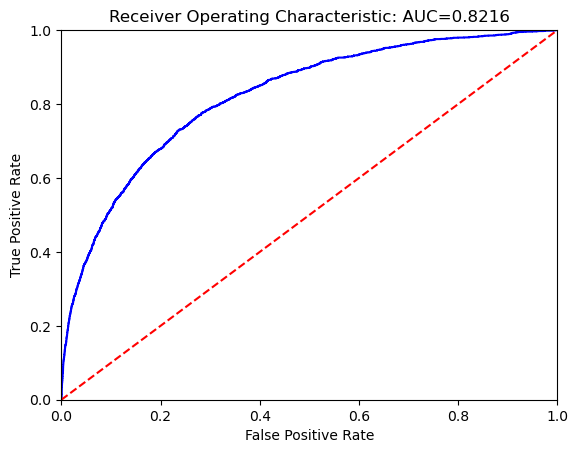

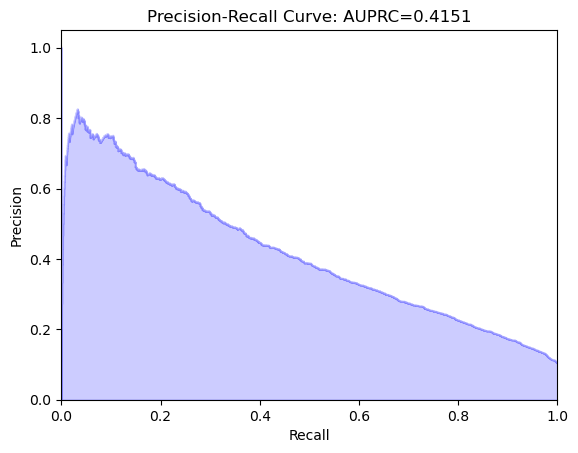

In [12]:
print("Logistic Regression:")
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression(random_state=random_seed)
start = time.time()
logreg.fit(X_train,y_train)
runtime = time.time()-start
import pickle
with open('task4_logreg.pickle', 'wb') as model_dump:
    pickle.dump(logreg, model_dump)
print('Training time:', runtime, 'seconds')
probs = logreg.predict_proba(X_test)
result = PlotROCCurve(probs[:,1],y_test, ci=confidence_interval, random_seed=random_seed)

results = ["LR"]
results.extend(result)
results.append(runtime)
result_list.append(results)



RandomForest:
Training time: 22.452422857284546 seconds
AUC: 0.9094414329272298
AUPRC: 0.6354611232315266
Sensitivity: 0.8387259858442871
Specificity: 0.8048092186489506
Score thresold: 0.13
2.5 97.5


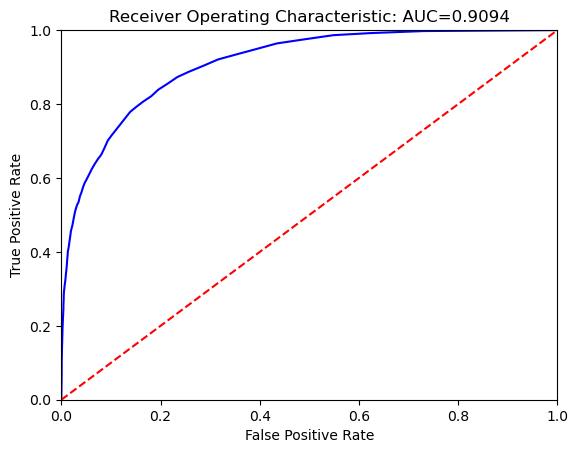

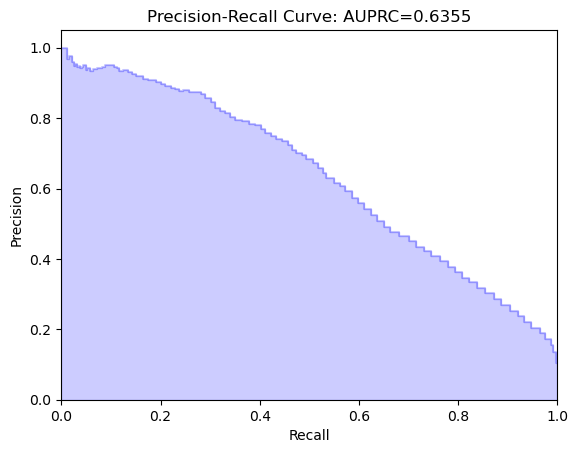

[0.05170843 0.00927404 0.0051066  0.00838889 0.01511827 0.00522117
 0.00866563 0.01442598 0.00308739 0.00605943 0.01010837 0.04174073
 0.0813894  0.005463   0.0038859  0.00210923 0.00105531 0.00128051
 0.00193821 0.00187194 0.0034931  0.00213952 0.00195583 0.00444156
 0.00488986 0.00436867 0.00440374 0.00244657 0.00565015 0.00217781
 0.00238028 0.0038021  0.00571622 0.00399052 0.00217013 0.00475451
 0.00451877 0.00230164 0.00325999 0.00094793 0.00593139 0.00420898
 0.00386598 0.00457677 0.00717698 0.00470655 0.00444163 0.0015573
 0.004526   0.00433181 0.0036953  0.00555847 0.0019734  0.00379965
 0.00369101 0.00292836 0.00195106 0.00543838 0.05295006 0.08069748
 0.06926383 0.03337918 0.06608481 0.05427298 0.10826604 0.05929707
 0.05372219]


In [13]:
print("RandomForest:")
from sklearn.ensemble import RandomForestClassifier
rf= RandomForestClassifier(random_state=random_seed)
start = time.time()
rf.fit(X_train,y_train)
runtime = time.time()-start
print('Training time:', runtime, 'seconds')
probs = rf.predict_proba(X_test)
result = PlotROCCurve(probs[:,1],y_test, ci=confidence_interval, random_seed=random_seed)
importances = rf.feature_importances_
print(importances)

results = ["RF"]
results.extend(result)
results.append(runtime)
result_list.append(results)

GradientBoosting:
Training time: 33.007073163986206 seconds
AUC: 0.9135711088776471
AUPRC: 0.6381243131894652
Sensitivity: 0.8281092012133469
Specificity: 0.8212710917749426
Score thresold: 0.10630775862660578
2.5 97.5


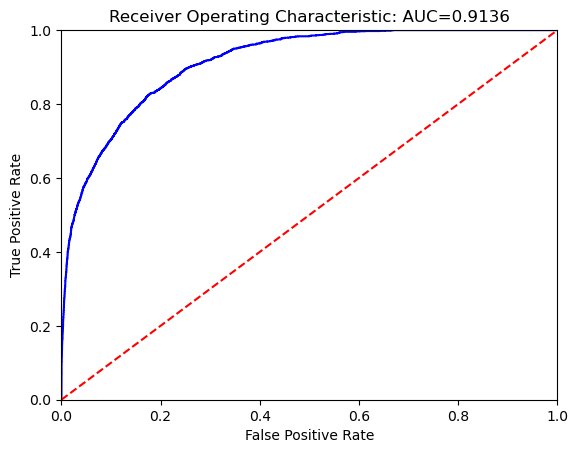

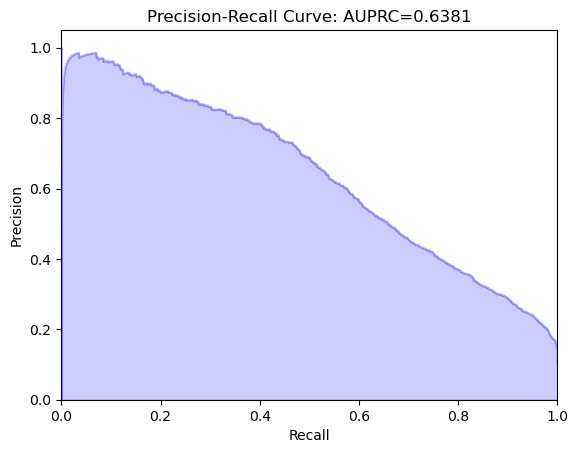

In [14]:
print("GradientBoosting:")
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=random_seed)
start = time.time()
gb.fit(X_train, y_train)
runtime = time.time()-start
print('Training time:', runtime, 'seconds')
test_probs = gb.predict_proba(X_test)
result = PlotROCCurve(test_probs[:,1],y_test, ci=confidence_interval, random_seed=random_seed)

results = ["GB"]
results.extend(result)
results.append(runtime)
result_list.append(results)

In [15]:
import pandas as pd
import numpy as np

test_probs = test_probs[:,1]

test_pred_df = pd.DataFrame({
    "sample_id": np.arange(len(y_test)),   # replace with real ID if available
    "y_true": y_test,
    "pred_prob_structured": test_probs
})

test_pred_df["y_true"] = test_pred_df["y_true"].astype(int)
test_pred_df.to_csv("structured_test_predictions_task4.csv", index=False)

test_pred_df.head()

,sample_id,y_true,pred_prob_structured
0,0,0,0.107265
1,1,0,0.004607
2,2,0,0.004326
3,3,0,0.003726
4,4,0,0.005754


GradientBoosting:
Training time: 33.10045266151428 seconds
AUC: 0.9123008325952339
AUPRC: 0.63851818478179
Sensitivity: 0.828760162601626
Specificity: 0.8186625925490657
Score thresold: 0.10578465686215091
2.5 97.5


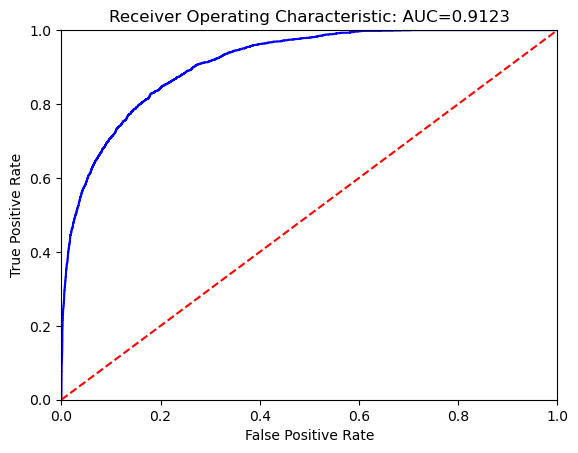

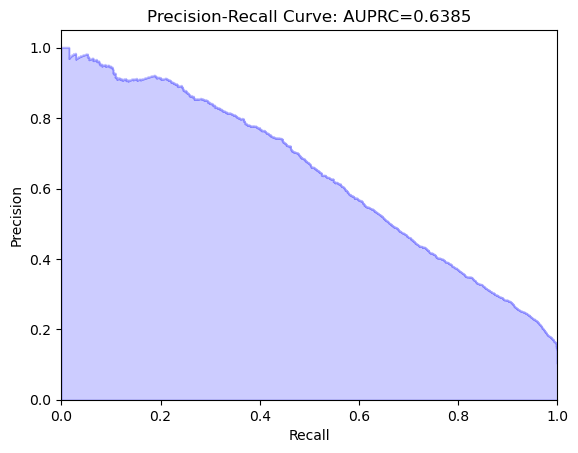

In [16]:
print("GradientBoosting:")
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=random_seed)
start = time.time()
gb.fit(X_train, y_train)
runtime = time.time()-start
print('Training time:', runtime, 'seconds')
val_probs = gb.predict_proba(X_val)
result = PlotROCCurve(val_probs[:,1],y_val, ci=confidence_interval, random_seed=random_seed)

results = ["GB"]
results.extend(result)
results.append(runtime)
result_list.append(results)

In [17]:
import pandas as pd
import numpy as np

val_probs = val_probs[:,1]

val_pred_df = pd.DataFrame({
    "sample_id": np.arange(len(y_val)),   # replace with real ID if available
    "y_true": y_val,
    "pred_prob_structured": val_probs
})

val_pred_df["y_true"] = val_pred_df["y_true"].astype(int)
val_pred_df.to_csv("structured_val_predictions_task4.csv", index=False)

val_pred_df.head()

,sample_id,y_true,pred_prob_structured
0,0,0,0.208576
1,1,0,0.182002
2,2,0,0.348863
3,3,1,0.866424
4,4,0,0.059331


In [18]:
class MLP(tf.keras.Model):
    def __init__(self):
        super(MLP, self).__init__()
        self.dense_1 = Dense(128, activation='relu')
        self.dense_2 = Dense(64, activation='relu')
        self.classifier = Dense(1, activation='sigmoid')

    def call(self, x):
        x = self.dense_1(x)
        x = self.dense_2(x)
        return self.classifier(x)

Epoch 1/20


2026-03-15 22:50:47.328716: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:129] retrieving CUDA diagnostic information for host: agc04
2026-03-15 22:50:47.328738: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:136] hostname: agc04
2026-03-15 22:50:47.328872: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:159] libcuda reported version is: NOT_FOUND: was unable to find libcuda.so DSO loaded into this program
2026-03-15 22:50:47.328905: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] kernel reported version is: 580.126.20


760/760 [==============================] - 2s 1ms/step - loss: 0.4898 - accuracy: 0.8957 - auc: 0.8246 - auprc: 0.3634 - tp: 3737.0000 - tn: 132313.0000 - precision: 0.5131 - recall: 0.2331
Epoch 2/20
760/760 [==============================] - 1s 1ms/step - loss: 0.2399 - accuracy: 0.9067 - auc: 0.8689 - auprc: 0.4988 - tp: 4910.0000 - tn: 132803.0000 - precision: 0.6164 - recall: 0.3063
Epoch 3/20
760/760 [==============================] - 1s 1ms/step - loss: 0.2391 - accuracy: 0.9076 - auc: 0.8711 - auprc: 0.5083 - tp: 5232.0000 - tn: 132623.0000 - precision: 0.6179 - recall: 0.3263
Epoch 4/20
760/760 [==============================] - 1s 1ms/step - loss: 0.2283 - accuracy: 0.9114 - auc: 0.8828 - auprc: 0.5346 - tp: 5517.0000 - tn: 132915.0000 - precision: 0.6521 - recall: 0.3441
Epoch 5/20
760/760 [==============================] - 1s 1ms/step - loss: 0.2227 - accuracy: 0.9128 - auc: 0.8875 - auprc: 0.5536 - tp: 5656.0000 - tn: 132987.0000 - precision: 0.6632 - recall: 0.3528
Epoch 

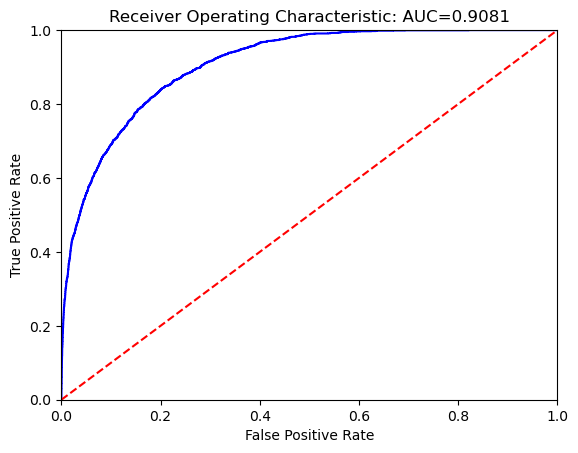

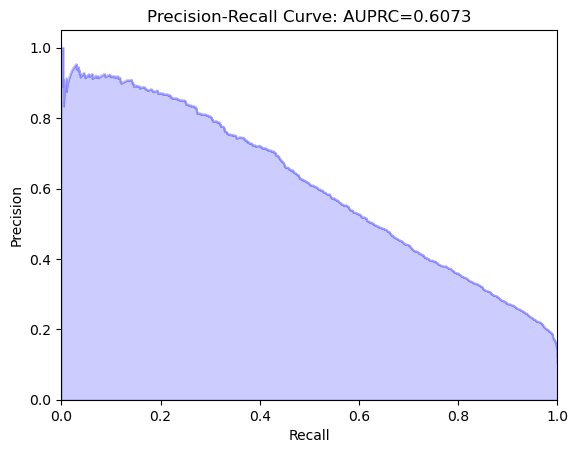

In [19]:
mlp = MLP()
mlp.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.Adam(learning_rate=0.001),
    metrics=[
        'accuracy',
        metrics.AUC(name='auc'),
        metrics.AUC(name='auprc', curve='PR'),
        metrics.TruePositives(name='tp'),
        metrics.TrueNegatives(name='tn'),
        metrics.Precision(name='precision'),
        metrics.Recall(name='recall'),
    ]
)

start = time.time()
mlp.fit(X_train.astype(np.float32), y_train, batch_size=200, epochs=20)
runtime = time.time() - start
print('Training time:', runtime, 'seconds')

mlp.save('critical_disposition_mlp_MV.keras')

print("MLP:")
probs = mlp.predict(X_test.astype(np.float32))
result = PlotROCCurve(probs, y_test, ci=confidence_interval, random_seed=random_seed)

results = ["MLP"]
results.extend(result)
results.append(runtime)
result_list.append(results)